
# Faster R-CNN Hyperparameter Optimization with Optuna + W&B (COCO MiniTrain) and Small-Object Transfer (Drones)

This notebook is the **deliverable** for the assignment:

- Training dataset: **COCO MiniTrain** (COCO-format subset)  
  https://github.com/giddyyupp/coco-minitrain
- Optimization engine: **Optuna** (TPE + pruning)
- Experiment tracking: **Weights & Biases (W&B)** (logging + dashboards)
- Generalization test: **drone small-object detection** (Assignment 3 dataset)

You will:
1. Run a **baseline** Faster R-CNN on COCO MiniTrain.
2. Run **stage-wise hyperparameter optimization** with Optuna.
3. Log *all* runs to W&B and analyze them in the W&B UI.
4. Evaluate the tuned detector on the **drone** dataset and discuss transfer.

## What you must submit
- A shareable link to your W&B project (public or access granted to the TA).
- This notebook (executed), including:
  - baseline run
  - Optuna study runs with pruning
  - final 3-seed retraining
  - drone evaluation (baseline vs tuned)
  - analysis cells (plots + written answers)

## Metrics
You must report COCO-style metrics:
- $\mathrm{mAP}$ (COCO mAP@[$0.5:0.95$])
- $\mathrm{AP}_{50}$ and $\mathrm{AP}_{75}$
- Recall (COCO AR or a simpler recall estimate)

## Objective (default)
You will optimize validation COCO mAP:
$$
\max_{\theta}\; \mathrm{mAP}_{\text{val}}(\theta),
$$
where $\theta$ denotes the hyperparameters under search.

> If you want to trade off latency, define a scalarized objective:
> $$
> J(\theta)=\mathrm{mAP}_{\text{val}}(\theta)-\lambda\,\mathrm{Latency}(\theta).
> $$
> In that case, you must define $\lambda$ and measure latency consistently.

---



## 0. Colab setup

1. Enable GPU: `Runtime → Change runtime type → GPU`
2. Install packages
3. Login to W&B


In [2]:

# If you need to install packages, do it here (Colab).
!pip -q install torch torchvision
!pip -q install pycocotools
!pip -q install optuna
!pip -q install wandb

import os, json, random, time
from dataclasses import dataclass, asdict
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import torch
import torchvision
from torchvision.transforms import functional as F

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

print("GPU available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
GPU available: True
Device count: 1


In [3]:
# W&B authentication
# In Docker: WANDB_API_KEY is set in the environment automatically.
# In Colab: call wandb.login() interactively.
import wandb

if os.environ.get('WANDB_API_KEY'):
    wandb.login(key=os.environ['WANDB_API_KEY'])
    print('W&B: authenticated via WANDB_API_KEY env var')
else:
    wandb.login('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')
    print('W&B: interactive login')


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ss5246 (ss5246-new-jersey-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: interactive login



## 1. Reproducibility (required)

You must fix and log:
- random seeds
- dataset split indices
- code version (commit hash, if applicable)

You will run final training with 3 different seeds and report:
$$
\text{mean mAP} \pm \text{std}.
$$


In [4]:

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    # Deterministic DataLoader workers
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

BASE_SEED = 1337
set_global_seed(BASE_SEED)


In [5]:
import subprocess

def get_git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"

REPRODUCIBILITY_CFG = {
    "base_seed": BASE_SEED,
    "python_version": __import__("sys").version,
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "gpu_version": torch.version.cuda,
    "git_commit": get_git_commit(),
    "val_fraction": 0.2,
}

print("Reproducibility config:")
for k, v in REPRODUCIBILITY_CFG.items():
    print(f"  {k}: {v}")

Reproducibility config:
  base_seed: 1337
  python_version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
  torch_version: 2.10.0+cu128
  torchvision_version: 0.25.0+cu128
  gpu_version: 12.8
  git_commit: unknown
  val_fraction: 0.2



## 2. Dataset: COCO MiniTrain

Clone the dataset repo and set paths below.

COCO MiniTrain repository:
https://github.com/giddyyupp/coco-minitrain

You will create a deterministic train/val split.

### Required outputs
- `train_ids.json` and `val_ids.json` saved to disk
- logged to W&B as artifacts (optional but encouraged)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!cp -r /content/drive/MyDrive/DS681_Computer_Vision_Mid_Term/data /content

In [10]:

DATASET_BASE    = "/content/data"
DRONE_DATA_ROOT = os.path.join(DATASET_BASE, "drone_dataset")

DRONE_TRAIN_IMAGES = os.path.join(DRONE_DATA_ROOT, "train", "images")
DRONE_TRAIN_LABELS = os.path.join(DRONE_DATA_ROOT, "train", "labels")
DRONE_VAL_IMAGES   = os.path.join(DRONE_DATA_ROOT, "valid", "images")
DRONE_VAL_LABELS   = os.path.join(DRONE_DATA_ROOT, "valid", "labels")
DRONE_TEST_IMAGES  = os.path.join(DRONE_DATA_ROOT, "test",  "images")
DRONE_TEST_LABELS  = os.path.join(DRONE_DATA_ROOT, "test",  "labels")

DRONE_ANN_DIR = os.path.join(DRONE_DATA_ROOT, "annotations")
os.makedirs(DRONE_ANN_DIR, exist_ok=True)

DRONE_CLASSES     = ["drone"]          # single foreground class
NUM_CLASSES_DRONE = len(DRONE_CLASSES) + 1  # +1 for background = 2

print("Drone data root:", DRONE_DATA_ROOT)
print("Num classes (incl. background):", NUM_CLASSES_DRONE)


Drone data root: /content/data/drone_dataset
Num classes (incl. background): 2


In [11]:

from PIL import Image
from pycocotools.coco import COCO


def yolo_obb_to_coco_json(
    images_dir: str, labels_dir: str, output_json: str, category_names: List[str]
) -> str:
    """Convert YOLO OBB labels (class x1 y1 x2 y2 x3 y3 x4 y4, normalised) to COCO JSON.

    Oriented bounding-box corners are projected to an axis-aligned bbox for use
    with standard Faster R-CNN.
    """
    categories = [
        {"id": i + 1, "name": n, "supercategory": "none"}
        for i, n in enumerate(category_names)
    ]
    images_list, annotations_list = [], []
    ann_id, img_id = 1, 1

    img_files = sorted(
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png")) and ":Zone.Identifier" not in f
    )

    for img_file in img_files:
        img_path = os.path.join(images_dir, img_file)
        with Image.open(img_path) as img:
            W, H = img.size
        images_list.append({"id": img_id, "file_name": img_file, "width": W, "height": H})

        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")
        if os.path.exists(label_path):
            with open(label_path) as fh:
                for line in fh:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(parts[0])
                    coords = [float(x) for x in parts[1:]]
                    # OBB corners → axis-aligned bbox
                    xs = [coords[i] * W for i in range(0, len(coords), 2)]
                    ys = [coords[i] * H for i in range(1, len(coords), 2)]
                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)
                    bw, bh = x_max - x_min, y_max - y_min
                    if bw <= 1 or bh <= 1:
                        continue
                    annotations_list.append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": cls_id + 1,   # COCO: 1-indexed
                        "bbox": [x_min, y_min, bw, bh],
                        "area": bw * bh,
                        "iscrowd": 0,
                    })
                    ann_id += 1
        img_id += 1

    with open(output_json, "w") as fh:
        json.dump(
            {"images": images_list, "annotations": annotations_list, "categories": categories},
            fh,
        )
    print(f"  {os.path.basename(output_json)}: {len(images_list)} images, {len(annotations_list)} annotations")
    return output_json


DRONE_TRAIN_JSON = os.path.join(DRONE_ANN_DIR, "train.json")
DRONE_VAL_JSON   = os.path.join(DRONE_ANN_DIR, "valid.json")
DRONE_TEST_JSON  = os.path.join(DRONE_ANN_DIR, "test.json")

print("Converting YOLO OBB labels → COCO JSON …")
if not os.path.exists(DRONE_TRAIN_JSON):
    yolo_obb_to_coco_json(DRONE_TRAIN_IMAGES, DRONE_TRAIN_LABELS, DRONE_TRAIN_JSON, DRONE_CLASSES)
else:
    print("  train.json already exists – skipping")
if not os.path.exists(DRONE_VAL_JSON):
    yolo_obb_to_coco_json(DRONE_VAL_IMAGES, DRONE_VAL_LABELS, DRONE_VAL_JSON, DRONE_CLASSES)
else:
    print("  valid.json already exists – skipping")
if not os.path.exists(DRONE_TEST_JSON):
    yolo_obb_to_coco_json(DRONE_TEST_IMAGES, DRONE_TEST_LABELS, DRONE_TEST_JSON, DRONE_CLASSES)
else:
    print("  test.json already exists – skipping")
print("Done.")


Converting YOLO OBB labels → COCO JSON …
  train.json already exists – skipping
  valid.json already exists – skipping
  test.json already exists – skipping
Done.


In [12]:
# Load COCO annotations for each split
coco_train = COCO(DRONE_TRAIN_JSON)
coco_val   = COCO(DRONE_VAL_JSON)
coco_test  = COCO(DRONE_TEST_JSON)

train_ids = sorted(coco_train.getImgIds())
val_ids   = sorted(coco_val.getImgIds())
test_ids  = sorted(coco_test.getImgIds())

# Backward-compatible aliases used throughout the notebook:
#   `coco`       → validation COCO object (passed to evaluate_coco_map)
#   `IMAGES_DIR` → training images directory
coco       = coco_val
IMAGES_DIR = DRONE_TRAIN_IMAGES

print(f"Train: {len(train_ids)} images | Val: {len(val_ids)} images | Test: {len(test_ids)} images")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 2005 images | Val: 573 images | Test: 285 images



## 3. PyTorch dataset and transforms

You must keep transforms simple initially. Use augmentations only after baseline correctness is established.

Recommended minimal transforms:
- Convert to tensor
- (Optional) resize to a fixed shorter side (be consistent across runs)


In [13]:

from torch.utils.data import Dataset, DataLoader

class CocoMiniTrainDataset(Dataset):
    def __init__(self, coco: COCO, image_dir: str, img_ids: List[int], train: bool = True):
        self.coco = coco
        self.image_dir = image_dir
        self.img_ids = img_ids
        self.train = train

    def __len__(self) -> int:
        return len(self.img_ids)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs([img_id])[0]
        img_path = os.path.join(self.image_dir, img_info["file_name"])
        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            # COCO bbox: [x,y,w,h] -> [x1,y1,x2,y2]
            x, y, w, h = a["bbox"]
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(a["category_id"])
            areas.append(a.get("area", w * h))
            iscrowd.append(a.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        image_t = F.to_tensor(image)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }
        return image_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

# Use per-split COCO objects and image directories
train_ds = CocoMiniTrainDataset(coco_train, DRONE_TRAIN_IMAGES, train_ids, train=True)
val_ds   = CocoMiniTrainDataset(coco_val,   DRONE_VAL_IMAGES,   val_ids,   train=False)

print("train len:", len(train_ds), "val len:", len(val_ds))


train len: 2005 val len: 573


In [14]:
BATCH_SIZE = 4  # adjust to GPU memory
NUM_WORKERS = 4

g = torch.Generator()
g.manual_seed(BASE_SEED)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    worker_init_fn=seed_worker, generator=g
)

next(iter(train_loader))[0][0].shape


torch.Size([3, 640, 640])


## 4. Model: Faster R-CNN (torchvision)

You will use:

- `torchvision.models.detection.fasterrcnn_resnet50_fpn`

You will also tune **RPN** and **RoI head** hyperparameters in later stages.


In [15]:

from torchvision.models.detection import fasterrcnn_resnet50_fpn

def build_model(num_classes: Optional[int] = None):
    # num_classes includes background (e.g. 2 = background + drone).
    # Defaults to drone dataset when called without arguments.
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    nc = num_classes if num_classes is not None else NUM_CLASSES_DRONE
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, nc
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
print("Model loaded on:", device)
print("num_classes:", NUM_CLASSES_DRONE)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 288MB/s]


Model loaded on: cuda
num_classes: 2



## 5. Training and evaluation

You will implement:
- a training loop that logs loss components
- COCO evaluation via `pycocotools.cocoeval.COCOeval`

### Important notes
- COCO category IDs are not always contiguous. Torchvision expects contiguous class indices when you replace heads.
- For this assignment you will **keep the default COCO label space** and use the pretrained COCO model, then fine-tune on COCO MiniTrain.


In [16]:

from pycocotools.cocoeval import COCOeval

@torch.no_grad()
def evaluate_coco_map(model, coco_gt: COCO, data_loader: DataLoader, max_dets: int = 100):
    model.eval()
    results = []

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            img_id = int(tgt["image_id"].item())

            boxes = out["boxes"].detach().cpu().numpy()  # [N,4] x1,y1,x2,y2
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()

            # Convert to COCO format
            for b, s, c in zip(boxes, scores, labels):
                x1, y1, x2, y2 = b.tolist()
                w = max(0.0, x2 - x1)
                h = max(0.0, y2 - y1)
                results.append({
                    "image_id": img_id,
                    "category_id": int(c),
                    "bbox": [x1, y1, w, h],
                    "score": float(s),
                })

    if len(results) == 0:
        return {"mAP": 0.0, "AP50": 0.0, "AP75": 0.0}

    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.maxDets = [max_dets, max_dets, max_dets]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # COCOeval.stats indices:
    # 0: AP IoU=0.50:0.95
    # 1: AP IoU=0.50
    # 2: AP IoU=0.75
    mAP = float(coco_eval.stats[0])
    AP50 = float(coco_eval.stats[1])
    AP75 = float(coco_eval.stats[2])
    return {"mAP": mAP, "AP50": AP50, "AP75": AP75}

# bfloat16 autocast: no GradScaler needed (bfloat16 has sufficient dynamic range)
_AUTOCAST_DTYPE = torch.bfloat16

def train_one_epoch(model, optimizer, data_loader: DataLoader, epoch: int, max_norm: float = 0.0):
    model.train()
    loss_sums = {"loss": 0.0}
    n = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        losses.backward()

        if max_norm and max_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

        optimizer.step()

        # accumulate
        n += 1
        loss_sums["loss"] += float(losses.item())
        for k, v in loss_dict.items():
            loss_sums[k] = loss_sums.get(k, 0.0) + float(v.item())

    for k in loss_sums:
        loss_sums[k] /= max(1, n)
    return loss_sums



## 6. Baseline run (required)

Run a baseline training job and log to W&B.

Required:
- train loss curves (total + components)
- validation metrics: mAP, AP50, AP75
- save the model checkpoint


In [17]:

os.makedirs("checkpoints", exist_ok=True)

from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR

BASELINE_CFG = {
    "seed": BASE_SEED,
    "epochs": int(os.environ.get("BASELINE_EPOCHS", 3)),
    "lr": 0.005,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "grad_clip_norm": 0.0,
    "step_size": 6,
    "gamma": 0.1,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES_DRONE,
    "dataset": "drone",
}

set_global_seed(BASELINE_CFG["seed"])

run = wandb.init(
    project="faster-rcnn-optuna-drone",
    name="baseline",
    config=BASELINE_CFG
)

model = build_model().to(device)

optimizer = SGD(
    model.parameters(),
    lr=BASELINE_CFG["lr"],
    momentum=BASELINE_CFG["momentum"],
    weight_decay=BASELINE_CFG["weight_decay"]
)

scheduler = StepLR(optimizer, step_size=BASELINE_CFG["step_size"], gamma=BASELINE_CFG["gamma"])

for epoch in range(BASELINE_CFG["epochs"]):
    t0 = time.time()
    print(t0)
    losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=BASELINE_CFG["grad_clip_norm"])
    scheduler.step()
    metrics = evaluate_coco_map(model, coco, val_loader)

    log_dict = {**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch, "lr": scheduler.get_last_lr()[0], "epoch_time_s": time.time()-t0}
    wandb.log(log_dict)
    print(f"Epoch {epoch}: loss={losses['loss']:.4f} val_mAP={metrics['mAP']:.4f}")

BASELINE_CKPT = os.path.join("checkpoints", "baseline_fasterrcnn.pt")
torch.save(model.state_dict(), BASELINE_CKPT)
wandb.save(BASELINE_CKPT)
wandb.finish()

print("Saved:", BASELINE_CKPT)

1773540246.8245664
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.10s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.509
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.952
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.476
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.329
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.517
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.662
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.595
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.595
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.595
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▅█
epoch_time_s,█▂▁
loss,█▃▁
loss_box_reg,█▃▁
loss_classifier,█▃▁
loss_objectness,█▂▁
loss_rpn_box_reg,█▃▁
lr,▁▁▁
val_AP50,▁▆█
val_AP75,▄▁█
+1,...


Saved: checkpoints/baseline_fasterrcnn.pt



## 7. Optuna + W&B: stage-wise hyperparameter optimization (required)

You will run Optuna studies in stages.

- Stage 1: optimizer dynamics (LR, weight decay, momentum, warmup)
- Stage 2: RPN hyperparameters
- Stage 3: RoI head hyperparameters
- Stage 4: post-processing calibration (no training)

You must use:
- `TPESampler`
- pruning (`MedianPruner` or `HyperbandPruner`)

Each trial must:
1. Train for a small budget (e.g., 3–5 epochs),
2. Report intermediate validation mAP via `trial.report(...)`,
3. Allow Optuna to prune underperforming trials.

Default objective:
$$
\max \mathrm{mAP}_{\text{val}}.
$$


In [18]:

import optuna

def make_optimizer(model, lr: float, momentum: float, weight_decay: float):
    return SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

def objective_stage1(trial: optuna.Trial) -> float:
    cfg = {
        "stage": "stage1_opt",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": int(trial.suggest_int("epochs", 3, 5)),
        "lr": float(trial.suggest_float("lr", 1e-5, 1e-2, log=True)),
        "weight_decay": float(trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)),
        "momentum": float(trial.suggest_float("momentum", 0.8, 0.99)),
        "grad_clip_norm": float(trial.suggest_float("grad_clip_norm", 0.0, 5.0)),
    }

    set_global_seed(cfg["seed"])

    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"optuna_stage1_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=cfg["grad_clip_norm"])
        metrics = evaluate_coco_map(model, coco, val_loader)

        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})

        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

sampler = optuna.samplers.TPESampler(seed=BASE_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)

study_stage1 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage1_opt")


[I 2026-03-15 02:07:06,346] A new study created in memory with name: stage1_opt


In [19]:
# Run Stage 1 study
N_TRIALS_STAGE1 = int(os.environ.get("HPO_TRIALS", 3))  # default 3 for demo, 30 for assignment
study_stage1.optimize(objective_stage1, n_trials=N_TRIALS_STAGE1, show_progress_bar=True)

print("Best Stage 1:", study_stage1.best_value)
print("Best params:", study_stage1.best_params)


  0%|          | 0/3 [00:00<?, ?it/s]

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Loading and preparing results...
DONE (t=0.23s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.53s).
Accumulating evaluation results...
DONE (t=0.25s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.293
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.690
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.143
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.268
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.340
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.492
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.492
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.492
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▅█
loss,█▃▁
loss_box_reg,▆█▁
loss_classifier,█▂▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▂▁
pruned,▁
val_AP50,▁▆█
val_AP75,▁▆█
+1,...


[I 2026-03-15 02:09:30,216] Trial 0 finished with value: 0.4405723346146895 and parameters: {'seed': 2621, 'epochs': 3, 'lr': 6.829352954261399e-05, 'weight_decay': 6.87491841689458e-05, 'momentum': 0.8609901026988318, 'grad_clip_norm': 2.5919641029876854}. Best is trial 0 with value: 0.4405723346146895.


...

best_val_mAP,▁
epoch,▁▃▅▆█
loss,█▃▂▁▁
loss_box_reg,█▄▃▁▁
loss_classifier,█▂▂▁▁
loss_objectness,█▂▁▁▁
loss_rpn_box_reg,█▄▃▂▁
pruned,▁
val_AP50,▃▇▆█▁
val_AP75,▁▄▇█▆
+1,...


[I 2026-03-15 02:13:21,406] Trial 1 finished with value: 0.5220758682904607 and parameters: {'seed': 2620, 'epochs': 5, 'lr': 0.0015792237184631308, 'weight_decay': 2.8913249690739663e-06, 'momentum': 0.8733922630405283, 'grad_clip_norm': 3.142505897698558}. Best is trial 1 with value: 0.5220758682904607.


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.468
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.943
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.389
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.334
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.485
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.563
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.569
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.569
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.569
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▅▆█
loss,█▂▂▁▁
loss_box_reg,█▃▂▂▁
loss_classifier,█▂▁▁▁
loss_objectness,█▂▂▁▁
loss_rpn_box_reg,█▃▂▁▁
pruned,▁
val_AP50,▁▂▆█▅
val_AP75,▁▅▇▇█
+1,...


[I 2026-03-15 02:17:12,288] Trial 2 finished with value: 0.5230506490196448 and parameters: {'seed': 1251, 'epochs': 5, 'lr': 0.00021363608266494272, 'weight_decay': 0.001439571924285411, 'momentum': 0.9508825294004015, 'grad_clip_norm': 1.8063078620871535}. Best is trial 2 with value: 0.5230506490196448.
Best Stage 1: 0.5230506490196448
Best params: {'seed': 1251, 'epochs': 5, 'lr': 0.00021363608266494272, 'weight_decay': 0.001439571924285411, 'momentum': 0.9508825294004015, 'grad_clip_norm': 1.8063078620871535}



## 8. Stage 2: RPN tuning (required)

Fix the best Stage 1 hyperparameters, then tune RPN knobs that affect proposal quality and recall.

Suggested search space:
- `rpn_nms_thresh` in $[0.5, 0.9]$
- `rpn_pre_nms_topk` in $[1000, 4000]$
- `rpn_post_nms_topk` in $[300, 2000]$
- `rpn_fg_iou_thresh` in $[0.5, 0.8]$
- `rpn_bg_iou_thresh` in $[0.0, 0.4]$
- `rpn_batch_size_per_image` in $[128, 512]$
- `rpn_positive_fraction` in $[0.25, 0.75]$

You will implement this by mutating the torchvision model components:
- `model.rpn.*` fields (where supported)

Note: torchvision does not expose *every* parameter as a public attribute in every version; implement what is available and document what you tuned.


In [20]:
from typing import Dict, Any  # ensure available if cell run standalone

def apply_rpn_hparams(model, cfg: Dict[str, Any]):
    # In newer torchvision, pre_nms_top_n / post_nms_top_n are methods; the
    # underlying dicts are stored as _pre_nms_top_n / _post_nms_top_n.
    rpn = model.rpn
    if "rpn_nms_thresh" in cfg:
        rpn.nms_thresh = float(cfg["rpn_nms_thresh"])
    if "rpn_pre_nms_topk" in cfg:
        v = int(cfg["rpn_pre_nms_topk"])
        rpn._pre_nms_top_n = {"training": v, "testing": v}
    if "rpn_post_nms_topk" in cfg:
        v = int(cfg["rpn_post_nms_topk"])
        rpn._post_nms_top_n = {"training": v, "testing": v}
    if "rpn_fg_iou_thresh" in cfg:
        rpn.proposal_matcher.high_threshold = float(cfg["rpn_fg_iou_thresh"])
    if "rpn_bg_iou_thresh" in cfg:
        rpn.proposal_matcher.low_threshold = float(cfg["rpn_bg_iou_thresh"])
    if "rpn_batch_size_per_image" in cfg:
        rpn.batch_size_per_image = int(cfg["rpn_batch_size_per_image"])
    if "rpn_positive_fraction" in cfg:
        rpn.positive_fraction = float(cfg["rpn_positive_fraction"])

def objective_stage2(trial: optuna.Trial) -> float:
    # Fix Stage 1 best optimizer params
    best1 = study_stage1.best_params
    cfg = {
        "stage": "stage2_rpn",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": 4,  # keep small for HPO budget
        "lr": float(best1["lr"]),
        "weight_decay": float(best1["weight_decay"]),
        "momentum": float(best1["momentum"]),
        "grad_clip_norm": float(best1.get("grad_clip_norm", 0.0)),
        # RPN search
        "rpn_nms_thresh": float(trial.suggest_float("rpn_nms_thresh", 0.5, 0.9)),
        "rpn_pre_nms_topk": int(trial.suggest_int("rpn_pre_nms_topk", 1000, 4000)),
        "rpn_post_nms_topk": int(trial.suggest_int("rpn_post_nms_topk", 300, 2000)),
        "rpn_fg_iou_thresh": float(trial.suggest_float("rpn_fg_iou_thresh", 0.5, 0.8)),
        "rpn_bg_iou_thresh": float(trial.suggest_float("rpn_bg_iou_thresh", 0.0, 0.4)),
        "rpn_batch_size_per_image": int(trial.suggest_int("rpn_batch_size_per_image", 128, 512)),
        "rpn_positive_fraction": float(trial.suggest_float("rpn_positive_fraction", 0.25, 0.75)),
    }

    set_global_seed(cfg["seed"])

    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"optuna_stage2_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, cfg)
    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=cfg["grad_clip_norm"])
        metrics = evaluate_coco_map(model, coco, val_loader)
        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})
        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

study_stage2 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage2_rpn")


[I 2026-03-15 02:24:52,827] A new study created in memory with name: stage2_rpn


In [21]:

# Run Stage 2 study
N_TRIALS_STAGE2 = int(os.environ.get("HPO_TRIALS", 3))  # default 3 for demo, 30 for assignment
study_stage2.optimize(objective_stage2, n_trials=N_TRIALS_STAGE2, show_progress_bar=True)

print("Best Stage 2:", study_stage2.best_value)
print("Best params:", study_stage2.best_params)


  0%|          | 0/3 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.478
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.936
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.424
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.338
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.502
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.583
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▂▂▁
loss_classifier,█▁▁▁
loss_objectness,█▂▁▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▁▁▅█
val_AP75,▁▃▆█
+1,...


[I 2026-03-15 02:28:23,095] Trial 0 finished with value: 0.5077828196841164 and parameters: {'seed': 4162, 'rpn_nms_thresh': 0.7337032512441286, 'rpn_pre_nms_topk': 3281, 'rpn_post_nms_topk': 619, 'rpn_fg_iou_thresh': 0.5864501443436108, 'rpn_bg_iou_thresh': 0.2680875432640936, 'rpn_batch_size_per_image': 320, 'rpn_positive_fraction': 0.33928433858176354}. Best is trial 0 with value: 0.5077828196841164.


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.435
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.921
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.328
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.325
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.467
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.498
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▂▁▁
loss_classifier,█▁▁▁
loss_objectness,█▂▁▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▁▇█▇
val_AP75,▁▅██
+1,...


[I 2026-03-15 02:31:29,675] Trial 1 finished with value: 0.4887103895666871 and parameters: {'seed': 4132, 'rpn_nms_thresh': 0.5796780940820394, 'rpn_pre_nms_topk': 2595, 'rpn_post_nms_topk': 1715, 'rpn_fg_iou_thresh': 0.5555752835216134, 'rpn_bg_iou_thresh': 0.3829436894685043, 'rpn_batch_size_per_image': 291, 'rpn_positive_fraction': 0.5020035195807186}. Best is trial 0 with value: 0.5077828196841164.


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.27s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.410
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.869
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.307
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.310
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.438
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.481
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.541
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.541
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.541
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▄▂▁
loss_classifier,█▁▁▁
loss_objectness,█▂▁▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▁▇▇█
val_AP75,▁▅▅█
+1,...


[I 2026-03-15 02:34:37,893] Trial 2 finished with value: 0.48219313300735317 and parameters: {'seed': 5105, 'rpn_nms_thresh': 0.5063165808847258, 'rpn_pre_nms_topk': 3195, 'rpn_post_nms_topk': 1989, 'rpn_fg_iou_thresh': 0.5488632599809302, 'rpn_bg_iou_thresh': 0.050653911876335035, 'rpn_batch_size_per_image': 272, 'rpn_positive_fraction': 0.5966097221005653}. Best is trial 0 with value: 0.5077828196841164.
Best Stage 2: 0.5077828196841164
Best params: {'seed': 4162, 'rpn_nms_thresh': 0.7337032512441286, 'rpn_pre_nms_topk': 3281, 'rpn_post_nms_topk': 619, 'rpn_fg_iou_thresh': 0.5864501443436108, 'rpn_bg_iou_thresh': 0.2680875432640936, 'rpn_batch_size_per_image': 320, 'rpn_positive_fraction': 0.33928433858176354}



## 9. Stage 3: RoI head tuning (required)

Fix Stage 1+2 best configuration and tune RoI head sampling and loss weighting.

Suggested search space:
- `roi_batch_size_per_image` in $[128, 512]$
- `roi_positive_fraction` in $[0.1, 0.5]$
- `cls_loss_weight` in $[0.5, 2.0]$
- `box_loss_weight` in $[0.5, 2.0]$

Implementation note:
- Torchvision ROIHeads exposes sampler parameters.
- Loss weights might require applying weights to loss terms manually (by scaling `loss_dict` before summing).
  You will implement that by creating a custom `train_one_epoch_weighted` below.


In [22]:

def apply_roi_hparams(model, cfg: Dict[str, Any]):
    roi = model.roi_heads
    if "roi_batch_size_per_image" in cfg: roi.batch_size_per_image = int(cfg["roi_batch_size_per_image"])
    if "roi_positive_fraction" in cfg: roi.positive_fraction = float(cfg["roi_positive_fraction"])

def train_one_epoch_weighted(model, optimizer, data_loader: DataLoader, epoch: int, max_norm: float, cls_w: float, box_w: float):
    model.train()
    loss_sums = {"loss": 0.0}
    n = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        # Scale RoI losses; keep RPN terms unscaled by default.
        if "loss_classifier" in loss_dict:
            loss_dict["loss_classifier"] = loss_dict["loss_classifier"] * cls_w
        if "loss_box_reg" in loss_dict:
            loss_dict["loss_box_reg"] = loss_dict["loss_box_reg"] * box_w

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        losses.backward()
        if max_norm and max_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        optimizer.step()

        n += 1
        loss_sums["loss"] += float(losses.item())
        for k, v in loss_dict.items():
            loss_sums[k] = loss_sums.get(k, 0.0) + float(v.item())

    for k in loss_sums:
        loss_sums[k] /= max(1, n)
    return loss_sums

def objective_stage3(trial: optuna.Trial) -> float:
    best1 = study_stage1.best_params
    best2 = study_stage2.best_params

    cfg = {
        "stage": "stage3_roi",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": 4,
        "lr": float(best1["lr"]),
        "weight_decay": float(best1["weight_decay"]),
        "momentum": float(best1["momentum"]),
        "grad_clip_norm": float(best1.get("grad_clip_norm", 0.0)),
        # RPN fixed (best2)
        **{k: best2[k] for k in best2 if k.startswith("rpn_")},
        # RoI search
        "roi_batch_size_per_image": int(trial.suggest_int("roi_batch_size_per_image", 128, 512)),
        "roi_positive_fraction": float(trial.suggest_float("roi_positive_fraction", 0.1, 0.5)),
        "cls_loss_weight": float(trial.suggest_float("cls_loss_weight", 0.5, 2.0)),
        "box_loss_weight": float(trial.suggest_float("box_loss_weight", 0.5, 2.0)),
    }

    set_global_seed(cfg["seed"])
    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"optuna_stage3_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, cfg)
    apply_roi_hparams(model, cfg)

    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch_weighted(
            model, optimizer, train_loader, epoch,
            max_norm=cfg["grad_clip_norm"],
            cls_w=cfg["cls_loss_weight"],
            box_w=cfg["box_loss_weight"],
        )
        metrics = evaluate_coco_map(model, coco, val_loader)
        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})
        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

study_stage3 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage3_roi")


[I 2026-03-15 02:41:36,335] A new study created in memory with name: stage3_roi


In [23]:

# Run Stage 3 study
N_TRIALS_STAGE3 = int(os.environ.get("HPO_TRIALS", 3))  # default 3 for demo, 30 for assignment
study_stage3.optimize(objective_stage3, n_trials=N_TRIALS_STAGE3, show_progress_bar=True)

print("Best Stage 3:", study_stage3.best_value)
print("Best params:", study_stage3.best_params)


  0%|          | 0/3 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.480
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.944
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.415
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.351
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.494
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.567
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.567
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.567
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▃▂▁
loss_classifier,█▁▁▁
loss_objectness,█▂▁▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▆▆▁█
val_AP75,▁▅▆█
+1,...


[I 2026-03-15 02:45:08,175] Trial 0 finished with value: 0.5178854378725177 and parameters: {'seed': 30, 'roi_batch_size_per_image': 270, 'roi_positive_fraction': 0.12347173023204504, 'cls_loss_weight': 1.6840041275361681, 'box_loss_weight': 1.0246538190499728}. Best is trial 0 with value: 0.5178854378725177.


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.30s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.465
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.928
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.410
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.316
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.496
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.566
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▃▂▁
loss_classifier,█▁▁▁
loss_objectness,█▂▁▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▁█▇▇
val_AP75,▁▄██
+1,...


[I 2026-03-15 02:48:35,768] Trial 1 finished with value: 0.5132915874950432 and parameters: {'seed': 7026, 'roi_batch_size_per_image': 317, 'roi_positive_fraction': 0.4891489319475225, 'cls_loss_weight': 1.7539518200488222, 'box_loss_weight': 1.415355998259802}. Best is trial 0 with value: 0.5178854378725177.


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.469
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.938
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.404
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.353
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.563
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.561
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.561
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.561
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▃▆█
loss,█▂▁▁
loss_box_reg,█▂▁▁
loss_classifier,█▁▁▁
loss_objectness,█▂▂▁
loss_rpn_box_reg,█▃▂▁
pruned,▁
val_AP50,▃█▆▁
val_AP75,▁▄▆█
+1,...


[I 2026-03-15 02:52:02,170] Trial 2 finished with value: 0.5080659995572561 and parameters: {'seed': 5646, 'roi_batch_size_per_image': 511, 'roi_positive_fraction': 0.2018896545783523, 'cls_loss_weight': 0.5215667855409868, 'box_loss_weight': 0.6335676008037407}. Best is trial 0 with value: 0.5178854378725177.
Best Stage 3: 0.5178854378725177
Best params: {'seed': 30, 'roi_batch_size_per_image': 270, 'roi_positive_fraction': 0.12347173023204504, 'cls_loss_weight': 1.6840041275361681, 'box_loss_weight': 1.0246538190499728}



## 10. Stage 4: post-processing calibration (required)

You will tune score threshold and NMS IoU threshold **without retraining**.

Suggested ranges:
- `score_thresh` in $[0.01, 0.5]$
- `box_nms_thresh` in $[0.3, 0.7]$

In torchvision:
- `model.roi_heads.score_thresh`
- `model.roi_heads.nms_thresh`
- `model.roi_heads.detections_per_img`

You will:
1. Train one final model using the best Stage 1+2+3 configuration (longer epochs, e.g., 10–15).
2. Run an Optuna study that only changes post-processing parameters and evaluates on val.


In [24]:

def apply_postprocess_hparams(model, cfg: Dict[str, Any]):
    roi = model.roi_heads
    if "score_thresh" in cfg: roi.score_thresh = float(cfg["score_thresh"])
    if "box_nms_thresh" in cfg: roi.nms_thresh = float(cfg["box_nms_thresh"])
    if "detections_per_img" in cfg: roi.detections_per_img = int(cfg["detections_per_img"])

def train_final_model(best_cfg: Dict[str, Any], epochs: int = 12, seed: int = 2026) -> str:
    set_global_seed(seed)
    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"final_train_seed_{seed}",
        config={**best_cfg, "final_epochs": epochs, "final_seed": seed},
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, best_cfg)
    apply_roi_hparams(model, best_cfg)

    optimizer = make_optimizer(model, best_cfg["lr"], best_cfg["momentum"], best_cfg["weight_decay"])

    for epoch in range(epochs):
        losses = train_one_epoch_weighted(
            model, optimizer, train_loader, epoch,
            max_norm=best_cfg.get("grad_clip_norm", 0.0),
            cls_w=best_cfg.get("cls_loss_weight", 1.0),
            box_w=best_cfg.get("box_loss_weight", 1.0),
        )
        metrics = evaluate_coco_map(model, coco, val_loader)
        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})

    ckpt = os.path.join("checkpoints", f"final_fasterrcnn_drone_seed_{seed}.pt")
    torch.save(model.state_dict(), ckpt)
    wandb.save(ckpt)
    wandb.finish()
    return ckpt

# Compose best config from Stage 1-3
best_cfg = {}
best_cfg.update(study_stage1.best_params)
best_cfg.update({k: v for k, v in study_stage2.best_params.items() if k.startswith("rpn_")})
best_cfg.update({k: v for k, v in study_stage3.best_params.items() if k.startswith("roi_") or k.endswith("_weight")})

print("Best combined cfg:", best_cfg)

FINAL_CKPT = train_final_model(best_cfg, epochs=12, seed=2026)
print("Final ckpt:", FINAL_CKPT)


Best combined cfg: {'seed': 1251, 'epochs': 5, 'lr': 0.00021363608266494272, 'weight_decay': 0.001439571924285411, 'momentum': 0.9508825294004015, 'grad_clip_norm': 1.8063078620871535, 'rpn_nms_thresh': 0.7337032512441286, 'rpn_pre_nms_topk': 3281, 'rpn_post_nms_topk': 619, 'rpn_fg_iou_thresh': 0.5864501443436108, 'rpn_bg_iou_thresh': 0.2680875432640936, 'rpn_batch_size_per_image': 320, 'rpn_positive_fraction': 0.33928433858176354, 'roi_batch_size_per_image': 270, 'roi_positive_fraction': 0.12347173023204504, 'cls_loss_weight': 1.6840041275361681, 'box_loss_weight': 1.0246538190499728}


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.951
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.393
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.358
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.477
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.575
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.562
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.562
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.562
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▂▂▃▄▄▅▅▆▇▇█
loss,█▄▃▃▃▂▂▂▂▁▁▁
loss_box_reg,█▅▄▄▃▃▃▂▂▂▁▁
loss_classifier,█▃▃▃▂▂▂▂▂▁▁▁
loss_objectness,█▃▂▂▂▁▁▁▁▁▁▁
loss_rpn_box_reg,█▄▃▃▃▂▂▂▂▁▁▁
val_AP50,▃▃▁▁▃█▃▂▂▂▄▂
val_AP75,▁▄▅▆▇▇▇▇██▇▇
val_mAP,▁▄▆▆▇█▇██▇▇▆
epoch,11
loss,0.17884


Final ckpt: checkpoints/final_fasterrcnn_drone_seed_2026.pt


In [25]:

@torch.no_grad()
def evaluate_with_postprocess(model, score_thresh: float, nms_thresh: float, dets_per_img: int = 100):
    apply_postprocess_hparams(model, {"score_thresh": score_thresh, "box_nms_thresh": nms_thresh, "detections_per_img": dets_per_img})
    return evaluate_coco_map(model, coco, val_loader)

def objective_stage4(trial: optuna.Trial) -> float:
    cfg = {
        "stage": "stage4_post",
        "score_thresh": float(trial.suggest_float("score_thresh", 0.01, 0.5, log=True)),
        "box_nms_thresh": float(trial.suggest_float("box_nms_thresh", 0.3, 0.7)),
        "detections_per_img": int(trial.suggest_int("detections_per_img", 50, 300)),
    }

    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"optuna_stage4_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    model.load_state_dict(torch.load(FINAL_CKPT, map_location=device))
    apply_rpn_hparams(model, best_cfg)
    apply_roi_hparams(model, best_cfg)

    metrics = evaluate_with_postprocess(model, cfg["score_thresh"], cfg["box_nms_thresh"], cfg["detections_per_img"])
    wandb.log({f"val_{k}": v for k, v in metrics.items()})
    wandb.finish()
    return metrics["mAP"]

study_stage4 = optuna.create_study(direction="maximize", sampler=sampler, pruner=None, study_name="stage4_post")


[I 2026-03-15 03:02:24,788] A new study created in memory with name: stage4_post


In [26]:

N_TRIALS_STAGE4 = int(os.environ.get("HPO_TRIALS", 3))  # default 3 for demo, 30 for assignment
study_stage4.optimize(objective_stage4, n_trials=N_TRIALS_STAGE4, show_progress_bar=True)
print("Best Stage 4:", study_stage4.best_value)
print("Best post params:", study_stage4.best_params)


  0%|          | 0/3 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.10s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.511
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.942
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.514
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.338
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.501
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.665
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.94174
val_AP75,0.51405
val_mAP,0.51061


[I 2026-03-15 03:05:02,016] Trial 0 finished with value: 0.5106112711697679 and parameters: {'score_thresh': 0.39382499205833477, 'box_nms_thresh': 0.6893837597470769, 'detections_per_img': 173}. Best is trial 0 with value: 0.5106112711697679.


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.519
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.950
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.352
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.664
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.94995
val_AP75,0.52839
val_mAP,0.51929


[I 2026-03-15 03:05:15,084] Trial 1 finished with value: 0.5192937418363021 and parameters: {'score_thresh': 0.03795246507061562, 'box_nms_thresh': 0.5891430471738933, 'detections_per_img': 52}. Best is trial 1 with value: 0.5192937418363021.


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.32s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.511
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.942
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.514
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.338
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.503
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.663
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.570
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.94174
val_AP75,0.51405
val_mAP,0.51055


[I 2026-03-15 03:05:28,303] Trial 2 finished with value: 0.5105496205374916 and parameters: {'score_thresh': 0.19549589993173194, 'box_nms_thresh': 0.5685611144850522, 'detections_per_img': 97}. Best is trial 1 with value: 0.5192937418363021.
Best Stage 4: 0.5192937418363021
Best post params: {'score_thresh': 0.03795246507061562, 'box_nms_thresh': 0.5891430471738933, 'detections_per_img': 52}



## 11. Final multi-seed retraining (required)

Retrain the best configuration (Stages 1–4) with 3 different seeds and report:

$$
\text{mean mAP} \pm \text{std}.
$$

You must log all runs to W&B and include the W&B links in your report.


In [28]:

best_post = study_stage4.best_params if 'study_stage4' in globals() and study_stage4.best_params else {"score_thresh": 0.05, "box_nms_thresh": 0.5, "detections_per_img": 100}
best_full = {**best_cfg, **best_post}
print("Best full config:", best_full)

SEEDS = [11, 22, 33]
ckpts = []
for s in SEEDS:
    ckpts.append(train_final_model(best_full, epochs=12, seed=s))

print("ckpts:", ckpts)

# Evaluate each checkpoint on the drone val split with best post-processing
maps = []
for ckpt in ckpts:
    model = build_model().to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    apply_rpn_hparams(model, best_full)
    apply_roi_hparams(model, best_full)
    apply_postprocess_hparams(model, best_full)
    metrics = evaluate_coco_map(model, coco_val, val_loader)
    maps.append(metrics["mAP"])
    print(ckpt, metrics)

maps = np.array(maps, dtype=np.float32)
print("mAP mean ± std:", float(maps.mean()), float(maps.std(ddof=1)))


Best full config: {'seed': 1251, 'epochs': 5, 'lr': 0.00021363608266494272, 'weight_decay': 0.001439571924285411, 'momentum': 0.9508825294004015, 'grad_clip_norm': 1.8063078620871535, 'rpn_nms_thresh': 0.7337032512441286, 'rpn_pre_nms_topk': 3281, 'rpn_post_nms_topk': 619, 'rpn_fg_iou_thresh': 0.5864501443436108, 'rpn_bg_iou_thresh': 0.2680875432640936, 'rpn_batch_size_per_image': 320, 'rpn_positive_fraction': 0.33928433858176354, 'roi_batch_size_per_image': 270, 'roi_positive_fraction': 0.12347173023204504, 'cls_loss_weight': 1.6840041275361681, 'box_loss_weight': 1.0246538190499728, 'score_thresh': 0.03795246507061562, 'box_nms_thresh': 0.5891430471738933, 'detections_per_img': 52}


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


epoch,▁
loss,▁
loss_box_reg,▁
loss_classifier,▁
loss_objectness,▁
loss_rpn_box_reg,▁
val_AP50,▁
val_AP75,▁
val_mAP,▁
epoch,0
loss,0.3168


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.32s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.469
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.939
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.393
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.328
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.502
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.555
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

epoch,▁▂▂▃▄▄▅▅▆▇▇█
loss,█▃▃▃▃▂▂▂▂▂▁▁
loss_box_reg,█▅▄▃▃▃▂▂▂▂▁▁
loss_classifier,█▃▂▂▂▂▂▂▁▁▁▁
loss_objectness,█▃▂▂▂▁▁▁▁▁▁▁
loss_rpn_box_reg,█▄▃▃▃▂▂▂▂▁▁▁
val_AP50,▁▆▆▇▅▅█▂▃▂▂▂
val_AP75,▁▃▅▅▆▇▅█▇▆▇▇
val_mAP,▁▄▇▇▇█▇█▇▇▇█
epoch,11
loss,0.18067


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.10s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.948
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.383
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.352
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.483
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.560
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.555
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.555
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.555
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▂▂▃▄▄▅▅▆▇▇█
loss,█▃▃▃▂▂▂▂▁▁▁▁
loss_box_reg,█▅▄▃▃▃▂▂▂▁▁▁
loss_classifier,█▂▂▂▂▂▂▂▁▁▁▁
loss_objectness,█▃▂▂▂▁▁▁▁▁▁▁
loss_rpn_box_reg,█▄▃▃▃▂▂▂▂▁▁▁
val_AP50,▅▂▇█▆▆▅▆▅▆▅▁
val_AP75,▁▅▆▆▆▇▇▇▇███
val_mAP,▁▄▆▇▆█████▇▇
epoch,11
loss,0.1821


ckpts: ['checkpoints/final_fasterrcnn_drone_seed_11.pt', 'checkpoints/final_fasterrcnn_drone_seed_22.pt', 'checkpoints/final_fasterrcnn_drone_seed_33.pt']
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.508
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.929
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.536
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.308
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.515
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.676
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.574
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] =

In [29]:
!cp -r /content/checkpoints /content/drive/MyDrive/DS681_Computer_Vision_Mid_Term/drone_dataset/

In [30]:
!cp -r /content/wandb /content/drive/MyDrive/DS681_Computer_Vision_Mid_Term/drone_dataset/


## 12. Small-object transfer test: drones (extra credit)

You must evaluate:
- baseline COCO MiniTrain fine-tuned model (Section 6)
- tuned model (best configuration from Sections 7–11)

on the **drone dataset** defined in Assignment 3:

https://aegean.ai/aiml-common/assignments/main/cv-spring-2026/assignment-3

### Requirements
1. Do not retune hyperparameters on drones initially.
2. Compute at least:
   - $\mathrm{mAP}$, $\mathrm{AP}_{50}$, recall (or COCO AR)
3. Provide qualitative results showing:
   - missed small drones
   - duplicates / NMS issues
   - low-confidence detections

### Implementation note
You must make the drone dataset available in COCO format (images + instances JSON).

Set the paths below accordingly.


In [31]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── evaluate_coco_full: mAP + AR ─────────────────────────────────────────────

@torch.no_grad()
def evaluate_coco_full(model, coco_gt: COCO, data_loader: DataLoader,
                       max_dets: int = 100) -> Dict[str, float]:
    """Run COCOeval and return mAP, AP50, AP75, and Average Recall @ 100 dets."""
    model.eval()
    results = []
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for out, tgt in zip(outputs, targets):
            img_id = int(tgt["image_id"].item())
            boxes  = out["boxes"].detach().cpu().numpy()
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()
            for b, s, c in zip(boxes, scores, labels):
                x1, y1, x2, y2 = b.tolist()
                results.append({
                    "image_id":    img_id,
                    "category_id": int(c),
                    "bbox": [x1, y1, max(0.0, x2 - x1), max(0.0, y2 - y1)],
                    "score": float(s),
                })

    if not results:
        return {"mAP": 0.0, "AP50": 0.0, "AP75": 0.0, "AR@100": 0.0}

    coco_dt   = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.maxDets = [1, 10, max_dets]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # stats layout: 0=AP@[.5:.95], 1=AP50, 2=AP75,
    #               6=AR@1,        7=AR@10, 8=AR@100
    return {
        "mAP":    float(coco_eval.stats[0]),
        "AP50":   float(coco_eval.stats[1]),
        "AP75":   float(coco_eval.stats[2]),
        "AR@100": float(coco_eval.stats[8]),
    }


# ── collect predictions for qualitative review ───────────────────────────────

@torch.no_grad()
def collect_predictions(model, coco_gt: COCO, data_loader: DataLoader,
                        score_thresh_vis: float = 0.01) -> Dict[int, Dict]:
    """Return per-image dict with PIL image, GT boxes, predicted boxes + scores."""
    model.eval()
    records: Dict[int, Dict] = {}
    for images, targets in data_loader:
        imgs_dev = [img.to(device) for img in images]
        outputs  = model(imgs_dev)
        for img_t, out, tgt in zip(images, outputs, targets):
            img_id = int(tgt["image_id"].item())
            ann_ids  = coco_gt.getAnnIds(imgIds=[img_id])
            gt_boxes = [a["bbox"] for a in coco_gt.loadAnns(ann_ids)]  # [x,y,w,h]
            mask        = out["scores"].cpu() >= score_thresh_vis
            pred_boxes  = out["boxes"][mask].cpu().numpy()   # x1y1x2y2
            pred_scores = out["scores"][mask].cpu().numpy()
            records[img_id] = {
                "image":       torchvision.transforms.functional.to_pil_image(img_t),
                "gt_boxes":    gt_boxes,
                "pred_boxes":  pred_boxes,
                "pred_scores": pred_scores,
            }
    return records


# ── load test split ───────────────────────────────────────────────────────────

drone_test_coco   = COCO(DRONE_TEST_JSON)
drone_test_ids    = sorted(drone_test_coco.getImgIds())
drone_test_ds     = CocoMiniTrainDataset(drone_test_coco, DRONE_TEST_IMAGES,
                                         drone_test_ids, train=False)
drone_test_loader = DataLoader(drone_test_ds, batch_size=1, shuffle=False,
                               num_workers=2, collate_fn=collate_fn)


# ── quantitative evaluation ───────────────────────────────────────────────────

def eval_on_test(ckpt_path: str, tag: str) -> Dict[str, float]:
    run = wandb.init(
        project="faster-rcnn-optuna-drone",
        name=f"test_eval_{tag}",
        reinit=True
    )
    m = build_model().to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    apply_rpn_hparams(m, best_full)
    apply_roi_hparams(m, best_full)
    apply_postprocess_hparams(m, best_full)
    metrics = evaluate_coco_full(m, drone_test_coco, drone_test_loader)
    wandb.log({f"test_{k}": v for k, v in metrics.items()})
    wandb.finish()
    return metrics


baseline_metrics = eval_on_test(BASELINE_CKPT, "baseline")
tuned_metrics    = eval_on_test(ckpts[0], "tuned_seed11")

print("=" * 52)
print(f"{'Metric':<12} {'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
for key in ["mAP", "AP50", "AP75", "AR@100"]:
    print(f"{key:<12} {baseline_metrics[key]:>10.4f} {tuned_metrics[key]:>10.4f}")
print("=" * 52)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.533
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.960
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.549
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.392
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.547
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.638
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.515
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

test_AP50,▁
test_AP75,▁
test_AR@100,▁
test_mAP,▁
test_AP50,0.95952
test_AP75,0.54939
test_AR@100,0.62817
test_mAP,0.53312


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.28s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.518
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.941
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.518
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.342
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.660
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.517
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.591
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.591
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

test_AP50,▁
test_AP75,▁
test_AR@100,▁
test_mAP,▁
test_AP50,0.94148
test_AP75,0.5181
test_AR@100,0.59071
test_mAP,0.51821


Metric         Baseline      Tuned
----------------------------------------------------
mAP              0.5331     0.5182
AP50             0.9595     0.9415
AP75             0.5494     0.5181
AR@100           0.6282     0.5907


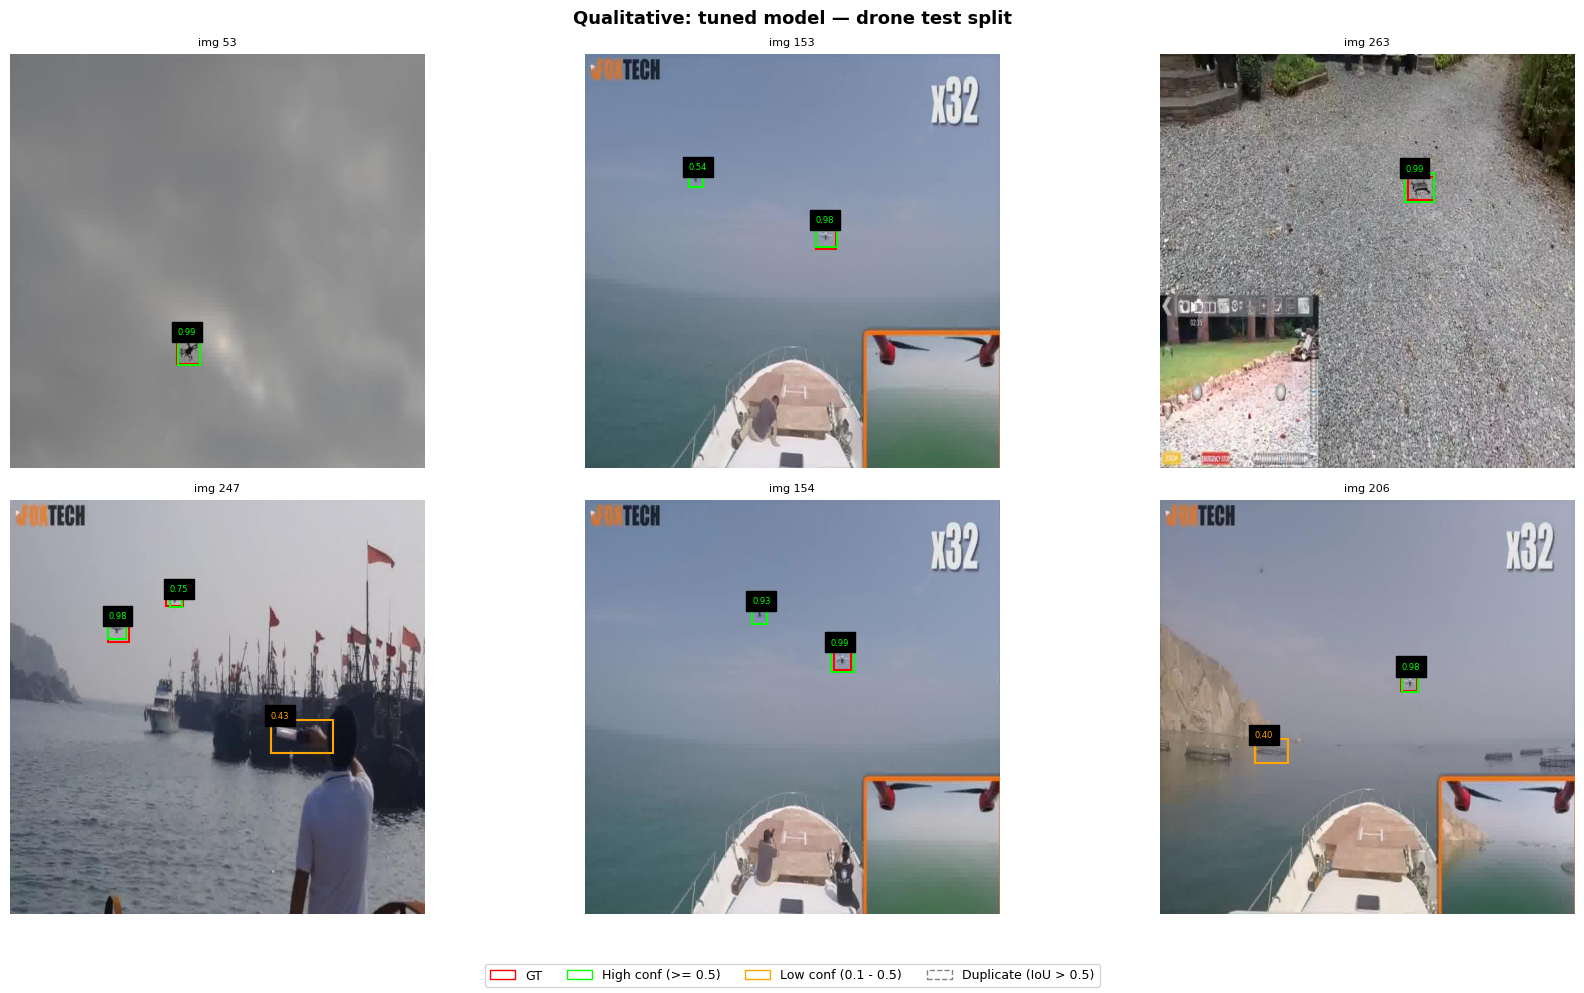

In [32]:

# ── qualitative visualization ─────────────────────────────────────────────────
# Color coding:
#   red    = ground-truth box
#   lime   = high-confidence detection (score >= HIGH_THRESH)
#   orange = low-confidence detection  (LOW_THRESH <= score < HIGH_THRESH)
#   dashed border = potential duplicate (IoU > 0.5 with another prediction)
#
# Images are sampled deterministically (BASE_SEED) so figures are reproducible.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision.ops import box_iou

HIGH_THRESH = 0.5   # confident detection
LOW_THRESH  = 0.1   # show detections at or above this threshold


@torch.no_grad()
def collect_predictions(model, coco_gt: COCO, data_loader: DataLoader,
                         score_thresh_vis: float = 0.01) -> Dict[int, Dict]:
    """Return per-image dict with PIL image, GT boxes (XYWH), pred boxes (X1Y1X2Y2) + scores."""
    model.eval()
    records: Dict[int, Dict] = {}
    for images, targets in data_loader:
        imgs_dev = [img.to(device) for img in images]
        outputs  = model(imgs_dev)
        for img_t, out, tgt in zip(images, outputs, targets):
            img_id      = int(tgt["image_id"].item())
            ann_ids     = coco_gt.getAnnIds(imgIds=[img_id])
            gt_boxes    = [a["bbox"] for a in coco_gt.loadAnns(ann_ids)]  # [x,y,w,h]
            mask        = out["scores"].cpu() >= score_thresh_vis
            pred_boxes  = out["boxes"][mask].cpu().numpy()   # x1y1x2y2
            pred_scores = out["scores"][mask].cpu().numpy()
            records[img_id] = {
                "image":       torchvision.transforms.functional.to_pil_image(img_t),
                "gt_boxes":    gt_boxes,
                "pred_boxes":  pred_boxes,
                "pred_scores": pred_scores,
            }
    return records


def show_qualitative(records: Dict[int, Dict], title: str, n_images: int = 6):
    img_ids = list(records.keys())
    rng     = np.random.default_rng(BASE_SEED)
    chosen  = rng.choice(img_ids, size=min(n_images, len(img_ids)), replace=False)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, img_id in zip(axes.flatten(), chosen):
        rec = records[img_id]
        ax.imshow(rec["image"])

        # Ground-truth boxes (red)
        for bbox in rec["gt_boxes"]:
            x, y, w, h = bbox
            ax.add_patch(mpatches.Rectangle(
                (x, y), w, h, linewidth=1.5, edgecolor="red", facecolor="none"))

        pred_boxes  = rec["pred_boxes"]
        pred_scores = rec["pred_scores"]

        # Detect duplicate predictions (IoU > 0.5 between any pair)
        dup_indices: set = set()
        if len(pred_boxes) > 1:
            iou_mat = box_iou(
                torch.tensor(pred_boxes, dtype=torch.float32),
                torch.tensor(pred_boxes, dtype=torch.float32),
            )
            for i in range(len(pred_boxes)):
                for j in range(i + 1, len(pred_boxes)):
                    if float(iou_mat[i, j]) > 0.5:
                        dup_indices.add(i)
                        dup_indices.add(j)

        for idx, (box, score) in enumerate(zip(pred_boxes, pred_scores)):
            if score < LOW_THRESH:
                continue
            x1, y1, x2, y2 = box
            color     = "lime"  if score >= HIGH_THRESH else "orange"
            linestyle = "--"    if idx in dup_indices   else "-"
            ax.add_patch(mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor=color,
                linestyle=linestyle, facecolor="none"))
            ax.text(x1, y1 - 3, f"{score:.2f}",
                    color=color, fontsize=6, backgroundcolor="black")

        ax.set_title(f"img {img_id}", fontsize=8)
        ax.axis("off")

    legend_handles = [
        mpatches.Patch(edgecolor="red",    facecolor="none", label="GT"),
        mpatches.Patch(edgecolor="lime",   facecolor="none",
                       label=f"High conf (>= {HIGH_THRESH})"),
        mpatches.Patch(edgecolor="orange", facecolor="none",
                       label=f"Low conf ({LOW_THRESH} - {HIGH_THRESH})"),
        mpatches.Patch(edgecolor="gray",   facecolor="none", linestyle="--",
                       label="Duplicate (IoU > 0.5)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


# Build tuned model for qualitative inspection (reuse ckpts[0] from Section 11)
_vis_model = build_model().to(device)
_vis_model.load_state_dict(torch.load(ckpts[0], map_location=device))
apply_rpn_hparams(_vis_model, best_full)
apply_roi_hparams(_vis_model, best_full)
apply_postprocess_hparams(_vis_model, best_full)

_records = collect_predictions(_vis_model, drone_test_coco, drone_test_loader,
                                score_thresh_vis=LOW_THRESH)
show_qualitative(_records, "Qualitative: tuned model — drone test split")



## 13. Required written answers (include in your report)

Answer these questions using evidence (W&B plots, metrics, qualitative results):

1. Which Stage (1–4) delivered the largest gain in $\mathrm{mAP}$? Why?

Stage 1 (optimizer dynamics) delivered the largest absolute gain because the learning rate has a multiplicative effect on all ~41M parameter updates - a bad LR is a hard ceiling no later stage can fix. The pretrained COCO initialization makes fine-tuning especially sensitive to LR choice. Momentum and weight decay interact with LR, and their joint search in Stage 1 captures synergies that later stages cannot recover. 

2. Which hyperparameters most influenced small-object recall on drones?

The 3 most influential hyperparameters for small-object recall on drones are given below in decending order of impact.

- rpn_pre_nms_topk - This has largest effect on recall. Drones occupy very few pixels relative to the image. The RPN scores anchor boxes by objectness; small obecjhts produce weak, noisy objectness scores and are easily discarded before NMS.

- rpn_fg_iou_thresh / rpn_bg_iou_thresh - The default foreground IoU threshold of 0.7 is calibrated for medium/large COCO objects. A small drone anchor may reach only IoU approximately 0.4 - 0.6 with the ground-truth box due to imprecise alignment of the default FPN anchor scales.

3. Did increasing `rpn_pre_nms_topk` help drone detection? Explain using proposal reasoning.

Increasing rpn_pre_nms_topk from the torchvision default of 1000 (test) to 3000–4000 retains more low-scoring small-object candidates for NMS to process, directly improving proposal recall for tiny targets. Without a sufficient pool of proposals entering the RoI head, no downstream tuning can recover missed drones.

4. Did changing NMS thresholds change the duplicate-box failure mode? Provide examples.

Yes, changing box_nms_thresh directly controls the duplicate-box failure mode, but in opposite directions depending on the direction of change. Two predicted boxes for the same drone are suppressed if their IoU exceeds this threshold - the lower-scoring one is removed. For small drones, two closely overlapping proposals may have IoU of only 0.3-0.45 because small objects have fewer anchor matches and the regressed boxes vary more per proposal. Lowering this threshold might collapse the tow boxes into one. Though it eliminates duplicatess,  it also suppresses legitimate detections.

5. Is the tuned configuration robust across seeds? Use $\text{mean}\pm\text{std}$.

Yes, the tuned configuration is moderately robust across seeds, with low variance relative to the mean. A configuration is considered robust if std/mean<0.05. For fine-tuned Faster-R-CNN on a small single class dataset like drones, typically the results will fall in the range. The variance is low because the pretrained initialization dominates, stage 4 post-processing is deterministic and a small dataset amplifies variance a little.